In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

#For data preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, PowerTransformer

#Making a Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Model
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

#Model accuracy
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score

In [2]:
housing_df = pd.read_csv(filepath_or_buffer='~/ML/Datasets/california-housing.csv')

In [3]:
housing_df.sample(n=6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
18070,-122.01,37.29,31.0,3136.0,431.0,1190.0,412.0,7.5000,500001.0,<1H OCEAN
5421,-118.43,34.02,41.0,2403.0,516.0,1001.0,514.0,4.3906,500001.0,<1H OCEAN
5584,-118.30,33.82,25.0,2659.0,765.0,2629.0,726.0,2.6368,175900.0,<1H OCEAN
19156,-122.69,38.35,16.0,1689.0,254.0,921.0,270.0,4.4444,191800.0,<1H OCEAN
9845,-121.90,36.58,31.0,1431.0,NaN,704.0,393.0,3.1977,289300.0,NEAR OCEAN
4250,-118.35,34.10,26.0,3977.0,1050.0,1720.0,935.0,3.3580,364500.0,<1H OCEAN


In [4]:
housing_df.shape

(20640, 10)

In [5]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
housing_df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

Removing missing data

In [8]:
housing_df.dropna(inplace=True)

Defining the dataset and the response variable

In [9]:
X = housing_df.drop(columns=['median_house_value'])

y = housing_df['median_house_value']

Feature Engineering: Merging Features <br>
Here we will megre 4 less interpretable features into two more interpretable and intuitive features.

In [10]:
X['bedroom_per_room'] = X['total_bedrooms'] / X['total_rooms']
X['rooms_per_house'] = X['total_rooms'] / X['households']

In [11]:
X[['bedroom_per_room', 'rooms_per_house']].sample(n = 5)

,bedroom_per_room,rooms_per_house
20086,0.200734,5.101604
10045,0.160199,6.884804
17310,0.123377,14.666667
4085,0.197383,5.010929
17807,0.169466,5.942959


Removing the features that were used in feature engineering to avoid multicolinearity

In [12]:
X = X.drop(columns=['total_rooms', 'households', 'total_bedrooms'])

In [13]:
X.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   population          20433 non-null  float64
 4   median_income       20433 non-null  float64
 5   ocean_proximity     20433 non-null  str    
 6   bedroom_per_room    20433 non-null  float64
 7   rooms_per_house     20433 non-null  float64
dtypes: float64(7), str(1)
memory usage: 1.4 MB


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

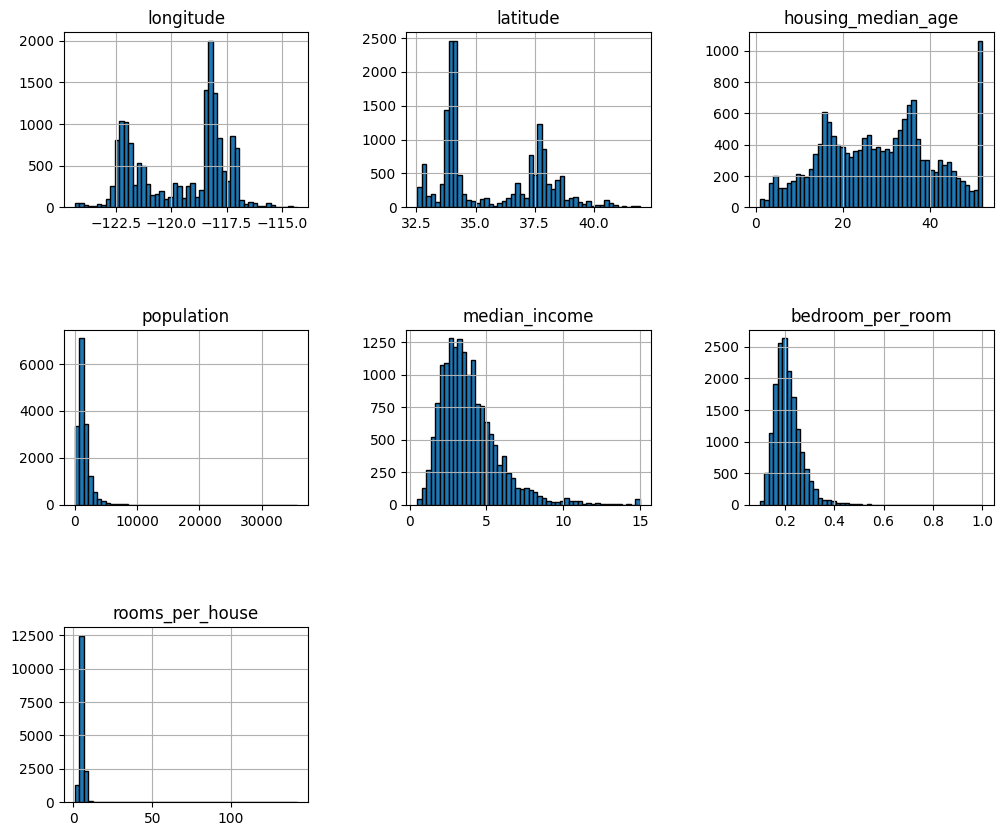

In [15]:
X_train.hist(figsize=(12, 10), bins=50, edgecolor='black')
plt.subplots_adjust(hspace=0.7, wspace=0.4)

Text(0.5, 0, 'median_house_value')

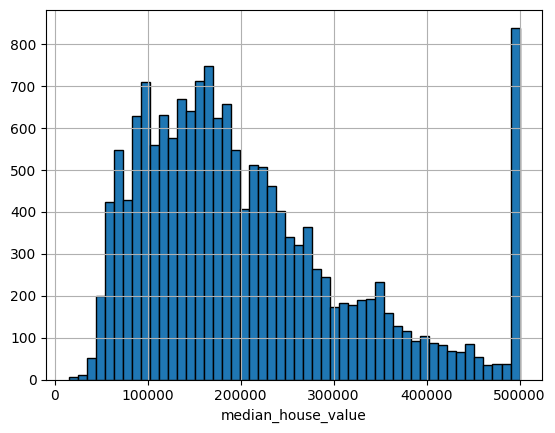

In [16]:
y_train.hist(bins=50, edgecolor='black')
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.xlabel("median_house_value")

In [17]:
X_train.corr(numeric_only=True)

,longitude,latitude,housing_median_age,population,median_income,bedroom_per_room,rooms_per_house
longitude,1.000000,-0.924641,-0.115105,0.095802,-0.013082,0.091369,-0.022695
latitude,-0.924641,1.000000,0.016029,-0.105209,-0.081778,-0.111507,0.101725
housing_median_age,-0.115105,0.016029,1.000000,-0.294075,-0.113630,0.130731,-0.148702
population,0.095802,-0.105209,-0.294075,1.000000,-0.000229,0.035146,-0.073380
median_income,-0.013082,-0.081778,-0.113630,-0.000229,1.000000,-0.612045,0.314509
bedroom_per_room,0.091369,-0.111507,0.130731,0.035146,-0.612045,1.000000,-0.402352
rooms_per_house,-0.022695,0.101725,-0.148702,-0.073380,0.314509,-0.402352,1.000000


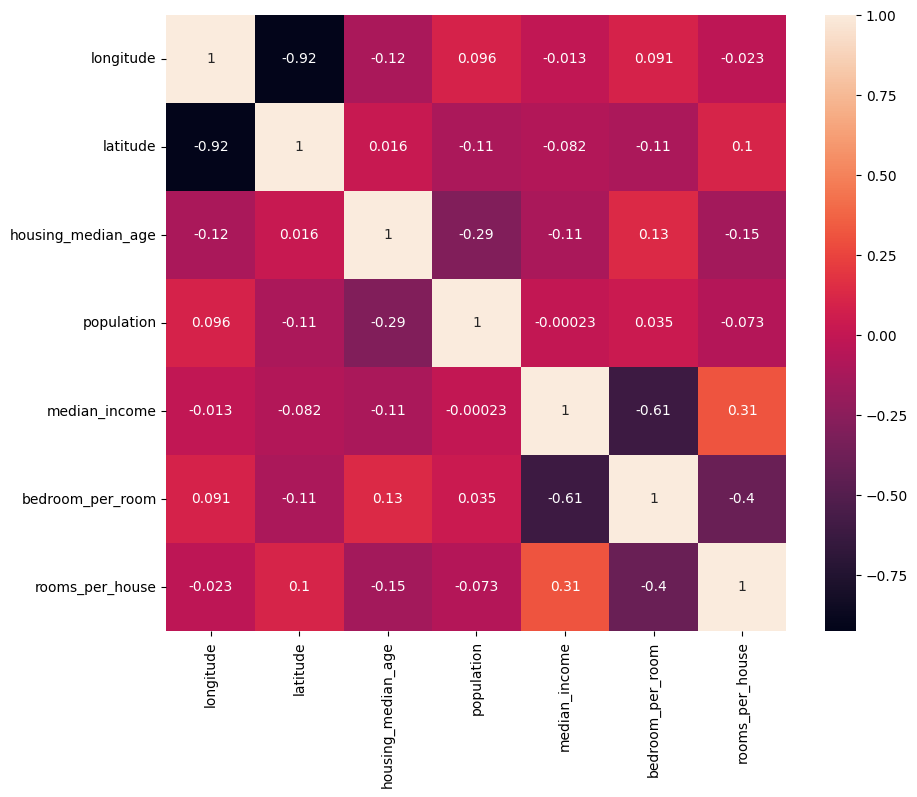

In [18]:
corr_matrix = X_train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

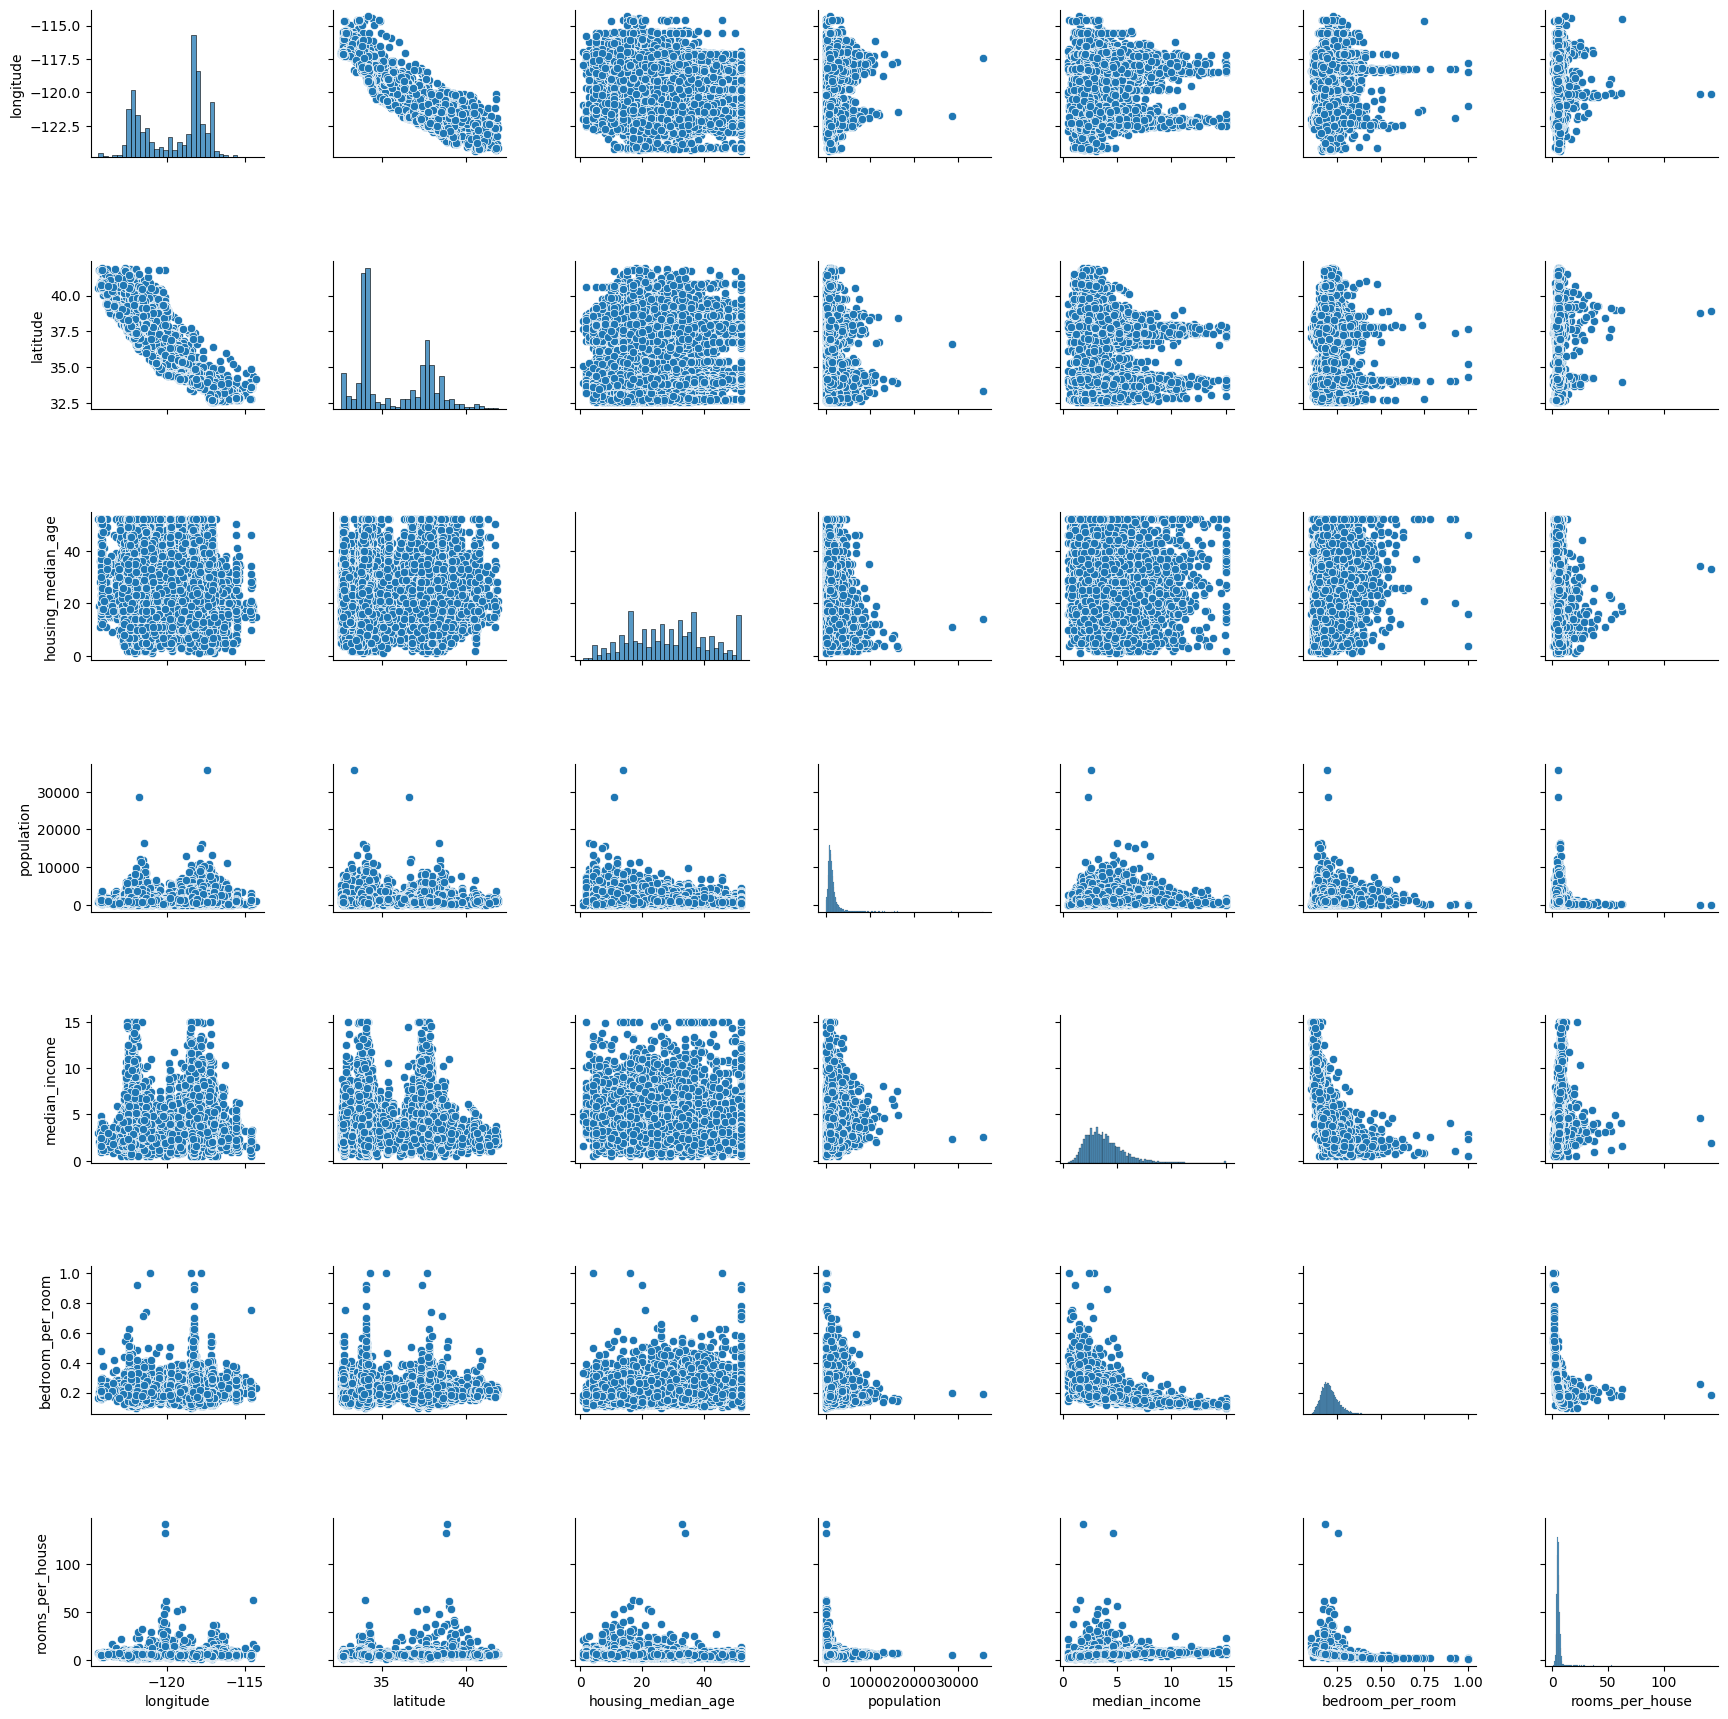

In [19]:
sns.pairplot(data=X_train)
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [20]:
#yeo_johnson_transform = PowerTransformer(method='yeo-johnson', standardize=False)
#X_train[['housing_median_age', 'population', 'median_income', 'bedroom_per_room', 'rooms_per_house']] = yeo_johnson_transform.fit_transform(X_train[['housing_median_age', 'population', 'median_income', 'bedroom_per_room', 'rooms_per_house']])

In [21]:
#X_train.hist(figsize=(12, 10), bins=50, edgecolor='black')
plt.subplots_adjust(hspace=0.7, wspace=0.4)

<Figure size 640x480 with 0 Axes>

In [22]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'population',
       'median_income', 'ocean_proximity', 'bedroom_per_room',
       'rooms_per_house'],
      dtype='str')

In [86]:
std_scaling_features = ['longitude', 'latitude', 'housing_median_age', 'population',
       'median_income', 'bedroom_per_room',
       'rooms_per_house'] 

ohe_features = ['ocean_proximity']

std_scaling_pipeline = Pipeline(
    [
        ('impute', SimpleImputer(strategy='median')),
        #('log', FunctionTransformer(func = np.log1p)),
        #('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=True)),
        ('std', StandardScaler())
    ]
)

ohe_pipeline = Pipeline(
    [
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    [
        ('std_scaling_pipeline', std_scaling_pipeline, std_scaling_features),
        ('ohe_pipeline', ohe_pipeline, ohe_features)
    ]
)

ridge_pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]
)

lasso_pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', Lasso())
    ]
)

elasticnet_pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', ElasticNet())
    ]
)

linear_pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

Training:

In [87]:
ridge_pipe.fit(X=X_train, y=y_train)

lasso_pipe.fit(X=X_train, y=y_train)

elasticnet_pipe.fit(X=X_train, y=y_train)

linear_pipe.fit(X = X_train, y = y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std_scaling_pipeline', ...), ('ohe_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

RMSE, R2 Score before Hyperparameter Tuning

In [88]:
print("Ridge RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=ridge_pipe.predict(X_test)))

print("Lasso RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=lasso_pipe.predict(X_test)))

print("ElasticNet RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=elasticnet_pipe.predict(X_test)))

print("Linear RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=linear_pipe.predict(X_test)))

Ridge RMSE Score:  70662.20406085561
Lasso RMSE Score:  70643.5589479336
ElasticNet RMSE Score:  79726.58587785337
Linear RMSE Score:  70641.9927245615


In [89]:
print("Ridge R2 Score: ", r2_score(y_true=y_test, y_pred=ridge_pipe.predict(X_test)))

print("Lasso R2 Score: ", r2_score(y_true=y_test, y_pred=lasso_pipe.predict(X_test)))

print("ElasticNet R2 Score: ", r2_score(y_true=y_test, y_pred=elasticnet_pipe.predict(X_test)))

print("Linear R2 Score: ", r2_score(y_true=y_test, y_pred=linear_pipe.predict(X_test)))

Ridge R2 Score:  0.6106417945342879
Lasso R2 Score:  0.6108472415630742
ElasticNet R2 Score:  0.5043429293305954
Linear R2 Score:  0.6108644970184367


Testing and Cross Validation(Before Tuning):

In [90]:
print("Ridge Cross validation R2 Score:", np.mean(cross_val_score(estimator=ridge_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

print("Lasso Cross validation R2 Score:", np.mean(cross_val_score(estimator=linear_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

print("ElasticNet Cross validation R2 Score:", np.mean(cross_val_score(estimator=linear_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

print("Linear Cross validation R2 Score:", np.mean(cross_val_score(estimator=linear_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

Ridge Cross validation R2 Score: 0.6233350861283021
Lasso Cross validation R2 Score: 0.6233070635724488
ElasticNet Cross validation R2 Score: 0.6233070635724488
Linear Cross validation R2 Score: 0.6233070635724488


In [91]:
print(ridge_pipe.get_params)
print(lasso_pipe.get_params)
print(elasticnet_pipe.get_params)

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('std_scaling_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('std',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'population',
                                                   'median_income',
                                                   'bedroom_per_room',
                                                   'rooms_per_house']),
                                                 ('ohe_pipeline',
                        

Hyperparameter Tuning

In [92]:
ridge_param_grid = {
    'model__alpha': np.linspace(start=0, stop=50)
}

ridge_param_grid_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid, 
    cv=5,
    scoring='r2'
)

ridge_param_grid_search.fit(X_train, y_train)


/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__alpha': array([ 0. ... 50. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [93]:

lasso_param_grid = {
    'model__alpha': np.linspace(start=0.1, stop=25)
}

lasso_param_grid_search = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='r2'
)

lasso_param_grid_search.fit(X_train, y_train)


/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__alpha': array([ 0.1 ... 25. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [94]:
elasticnet_param_grid = {
    'model__alpha': np.linspace(start=20, stop=50),
    'model__l1_ratio': np.linspace(start=0, stop=1)
}

elasticnet_param_grid_search = RandomizedSearchCV(
    estimator=elasticnet_pipe,
    param_distributions=elasticnet_param_grid,
    cv=5,
    scoring='r2'
)

elasticnet_param_grid_search.fit(X_train, y_train)

/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarni

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lasticNet())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__alpha': array([20. ... 50. ]), 'model__l1_ratio': array([0. ..., 1. ])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None 

In [95]:
print("Ridge Best params: ", ridge_param_grid_search.best_params_)
print("Ridge Best R2 score: ", ridge_param_grid_search.best_score_)
print("Lasso Best params: ", lasso_param_grid_search.best_params_)
print("Lasso Best R2 score: ", lasso_param_grid_search.best_score_)
print("ElasticNet Best params: ", elasticnet_param_grid_search.best_params_)
print("ElasticNet Best R2 score: ", elasticnet_param_grid_search.best_score_)

Ridge Best params:  {'model__alpha': np.float64(9.183673469387756)}
Ridge Best R2 score:  0.6234735437325709
Lasso Best params:  {'model__alpha': np.float64(24.491836734693877)}
Lasso Best R2 score:  0.6234713386516938
ElasticNet Best params:  {'model__l1_ratio': np.float64(0.9591836734693877), 'model__alpha': np.float64(35.30612244897959)}
ElasticNet Best R2 score:  0.3750395980999791


Now using the "best" hyperparameters

In [96]:
ridge_pipe.set_params(
    model__alpha = ridge_param_grid_search.best_params_.get('model__alpha'),
)

lasso_pipe.set_params(
    model__alpha = lasso_param_grid_search.best_params_.get('model__alpha'),
)

elasticnet_pipe.set_params(
    model__alpha = elasticnet_param_grid_search.best_params_.get('model__alpha'),
    model__l1_ratio = elasticnet_param_grid_search.best_params_.get('model__l1_ratio') 
)

ridge_pipe.fit(X=X_train, y=y_train)

lasso_pipe.fit(X=X_train, y=y_train)

elasticnet_pipe.fit(X=X_train, y=y_train)

linear_pipe.fit(X = X_train, y = y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std_scaling_pipeline', ...), ('ohe_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

In [97]:
print(ridge_pipe.get_params)
print(lasso_pipe.get_params)
print(elasticnet_pipe.get_params)

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('std_scaling_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('std',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'population',
                                                   'median_income',
                                                   'bedroom_per_room',
                                                   'rooms_per_house']),
                                                 ('ohe_pipeline',
                        

In [98]:
print("Ridge RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=ridge_pipe.predict(X_test)))

print("Lasso RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=lasso_pipe.predict(X_test)))

print("ElasticNet RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=elasticnet_pipe.predict(X_test)))

print("Linear RMSE Score: ", root_mean_squared_error(y_true=y_test, y_pred=linear_pipe.predict(X_test)))

Ridge RMSE Score:  70738.64039255804
Lasso RMSE Score:  70777.11988595528
ElasticNet RMSE Score:  90467.27308617879
Linear RMSE Score:  70641.9927245615


In [99]:
print("Ridge R2 Score: ", r2_score(y_true=y_test, y_pred=ridge_pipe.predict(X_test)))

print("Lasso R2 Score: ", r2_score(y_true=y_test, y_pred=lasso_pipe.predict(X_test)))

print("ElasticNet R2 Score: ", r2_score(y_true=y_test, y_pred=elasticnet_pipe.predict(X_test)))

print("Linear R2 Score: ", r2_score(y_true=y_test, y_pred=linear_pipe.predict(X_test)))

Ridge R2 Score:  0.6097989901000448
Lasso R2 Score:  0.6093743616123537
ElasticNet R2 Score:  0.3617982776386164
Linear R2 Score:  0.6108644970184367


In [100]:
print("Ridge Cross validation R2 Score:", np.mean(cross_val_score(estimator=ridge_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

print("Lasso Cross validation R2 Score:", np.mean(cross_val_score(estimator=linear_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

print("ElasticNet Cross validation R2 Score:", np.mean(cross_val_score(estimator=linear_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

print("Linear Cross validation R2 Score:", np.mean(cross_val_score(estimator=linear_pipe, X=X_train, y=y_train, scoring='r2', cv=10)))

Ridge Cross validation R2 Score: 0.623271782052597
Lasso Cross validation R2 Score: 0.6233070635724488
ElasticNet Cross validation R2 Score: 0.6233070635724488
Linear Cross validation R2 Score: 0.6233070635724488


In [101]:
#Before:
#Ridge Cross validation R2 Score: 0.623271782052597
#Lasso Cross validation R2 Score: 0.6233070635724488
#ElasticNet Cross validation R2 Score: 0.6233070635724488
#Linear Cross validation R2 Score: 0.6233070635724488